In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
MEMBER, STUDENT_ID, MODEL_NAME = 'Ranasinghe R.M.M.K.', 'IT25101541', 'Random Forest'
print(f'{MEMBER} ({STUDENT_ID}) - {MODEL_NAME}')

Ranasinghe R.M.M.K. (IT25101541) - Random Forest


In [2]:
# data loading and preprocessing
# load data
DATA = 'fitness_dataset.csv'
if not os.path.exists(DATA):
    try:
        from google.colab import files
        up = files.upload(); DATA = list(up.keys())[0]
    except ImportError:
        raise FileNotFoundError('Put fitness_dataset.csv next to this notebook.')
df = pd.read_csv(DATA)
print('Shape:', df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])
print(df['smokes'].value_counts().to_dict())
df.head()

Saving fitness_dataset.csv to fitness_dataset.csv
Shape: (2000, 11)
sleep_hours    160
dtype: int64
{'yes': 711, '0': 581, 'no': 518, '1': 190}


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


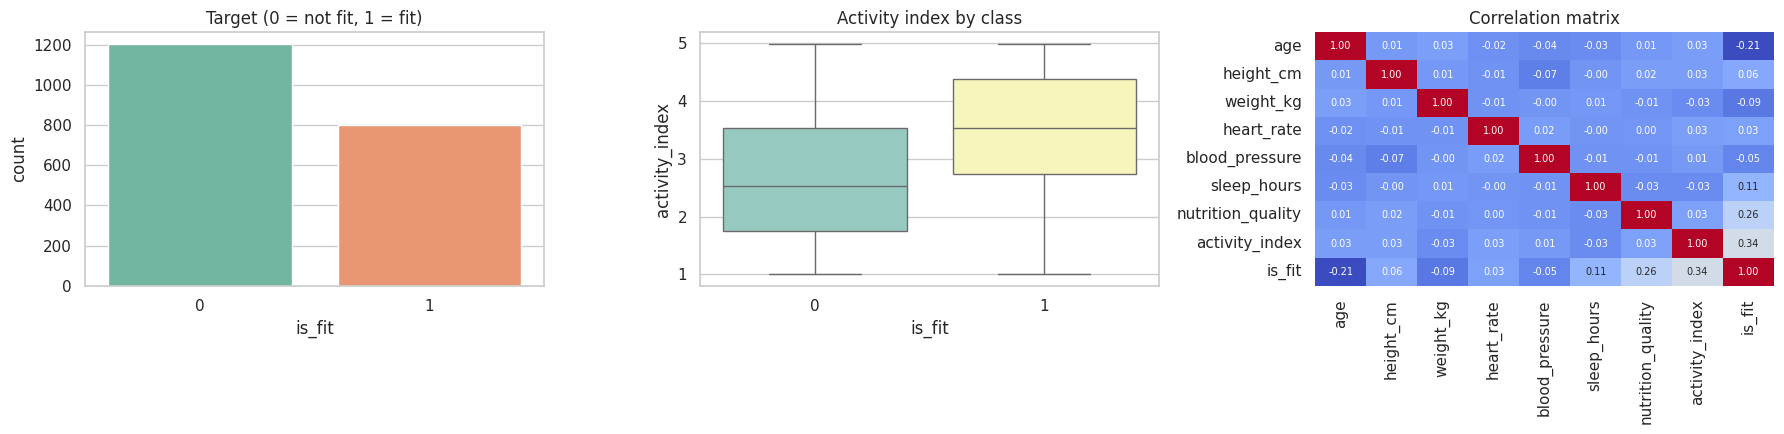

In [3]:
# eda
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
sns.countplot(data=df, x='is_fit', palette='Set2', ax=ax[0]); ax[0].set_title('Target (0 = not fit, 1 = fit)')
sns.boxplot(data=df, x='is_fit', y='activity_index', palette='Set3', ax=ax[1]); ax[1].set_title('Activity index by class')
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=False, ax=ax[2], annot_kws={'size': 7}); ax[2].set_title('Correlation matrix')
plt.tight_layout(); plt.show()

In [4]:
# cleaning, features, split
d = df.copy()
d['smokes'] = d['smokes'].astype(str).str.lower().map({'yes': 1, '1': 1, 'no': 0, '0': 0})
d['gender'] = (d['gender'] == 'M').astype(int)
d['bmi'] = d['weight_kg'] / (d['height_cm'] / 100) ** 2

y = d['is_fit']
BASE_COLS = ['age', 'height_cm', 'weight_kg', 'heart_rate', 'blood_pressure', 'sleep_hours',
             'nutrition_quality', 'activity_index', 'smokes', 'gender']
X = d[BASE_COLS + ['bmi']]
print(y.value_counts(normalize=True).round(3).to_dict())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print('Train:', X_train.shape, '| Test:', X_test.shape)

{0: 0.6, 1: 0.4}
Train: (1600, 11) | Test: (400, 11)


In [5]:
# preprocessing variants
VARIANTS = {
 'V1 Median impute, no scaling'  : dict(cols=BASE_COLS,                                        scaler=None,       pca=False),
 'V2 Median + StandardScaler'    : dict(cols=BASE_COLS,                                        scaler='standard', pca=False),
 'V3 Median + RobustScaler'      : dict(cols=BASE_COLS,                                        scaler='robust',   pca=False),
 'V4 Standard + BMI feature'     : dict(cols=BASE_COLS + ['bmi'],                              scaler='standard', pca=False),
 'V5 Standard, gender removed'   : dict(cols=[c for c in BASE_COLS if c != 'gender'],          scaler='standard', pca=False),
 'V6 Standard + PCA (95% var)'  : dict(cols=BASE_COLS,                                        scaler='standard', pca=True),
}

def make_pipeline(v, clf):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if v['scaler'] == 'standard': steps.append(('scaler', StandardScaler()))
    if v['scaler'] == 'robust':   steps.append(('scaler', RobustScaler()))
    if v['pca']:                  steps.append(('pca', PCA(n_components=0.95, random_state=42)))
    steps.append(('clf', clf))
    return Pipeline(steps)

def get_scores(model, X_):
    return model.predict_proba(X_)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_)

def evaluate(model, X_, y_):
    p = model.predict(X_)
    return dict(Accuracy=accuracy_score(y_, p), Precision=precision_score(y_, p), Recall=recall_score(y_, p),
                F1=f1_score(y_, p), ROC_AUC=roc_auc_score(y_, get_scores(model, X_)))

cv = KFold(n_splits=5, shuffle=True, random_state=42)
BASE = RandomForestClassifier(random_state=42, n_jobs=-1)
print('Base estimator:', BASE)

Base estimator: RandomForestClassifier(n_jobs=-1, random_state=42)


,#Features,CV F1 (mean),CV F1 (std),Test Acc,Test F1,Test AUC,Time (s)
Variant,,,,,,,
"V1 Median impute, no scaling",10,0.6811,0.0089,0.7600,0.6712,0.8051,5.3492
V2 Median + StandardScaler,10,0.6841,0.0131,0.7600,0.6712,0.8038,2.8373
V3 Median + RobustScaler,10,0.6841,0.0125,0.7550,0.6621,0.8044,3.7104
V4 Standard + BMI feature,11,0.7035,0.0240,0.7625,0.6667,0.8229,2.6270
"V5 Standard, gender removed",9,0.6789,0.0241,0.7475,0.6505,0.7935,2.6915
V6 Standard + PCA (95% var),10,0.6986,0.0242,0.7875,0.7157,0.8286,3.3040


Best preprocessing by 5-fold CV F1: V4 Standard + BMI feature


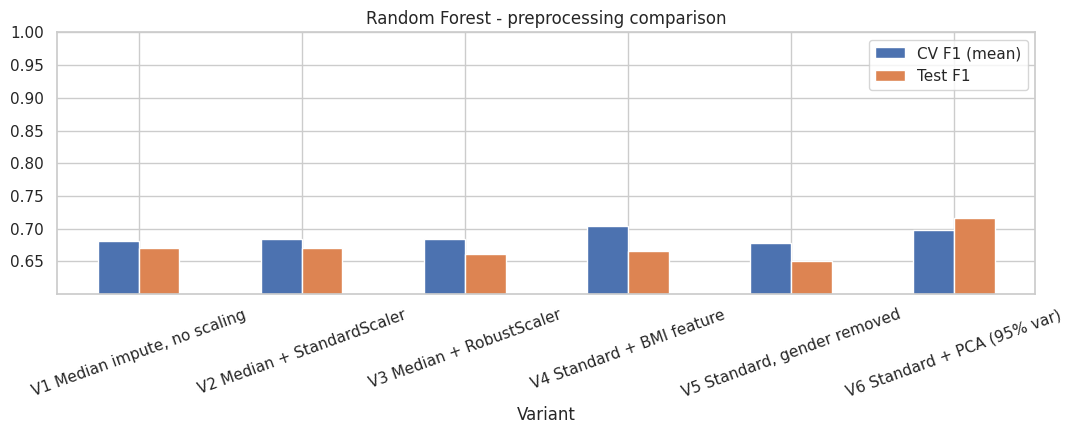

In [6]:
# preprocessing comparison
# preprocessing comparison, 5-fold cv
rows, n_fits = [], 0
for name, v in VARIANTS.items():
    t0 = time.time()
    pipe = make_pipeline(v, clone(BASE))
    cv_f1 = cross_val_score(pipe, X_train[v['cols']], y_train, cv=cv, scoring='f1'); n_fits += cv.get_n_splits()
    pipe.fit(X_train[v['cols']], y_train); n_fits += 1
    m = evaluate(pipe, X_test[v['cols']], y_test)
    rows.append({'Variant': name, '#Features': len(v['cols']), 'CV F1 (mean)': cv_f1.mean(), 'CV F1 (std)': cv_f1.std(),
                 'Test Acc': m['Accuracy'], 'Test F1': m['F1'], 'Test AUC': m['ROC_AUC'], 'Time (s)': time.time() - t0})
res_A = pd.DataFrame(rows).set_index('Variant')
display(res_A.round(4))
best_variant = res_A['CV F1 (mean)'].idxmax(); best_v = VARIANTS[best_variant]
print(f'Best preprocessing by 5-fold CV F1: {best_variant}')

ax = res_A[['CV F1 (mean)', 'Test F1']].plot.bar(figsize=(11, 4.5), rot=20, color=['#4c72b0', '#dd8452'])
ax.set_ylim(max(0, res_A[['CV F1 (mean)', 'Test F1']].min().min() - 0.05), 1); ax.set_title(f'{MODEL_NAME} - preprocessing comparison')
plt.tight_layout(); plt.show()

In [7]:
# hyperparameter tuning
# grid search
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [5, 10, None],
    'clf__min_samples_split': [2, 5],
}
gs = GridSearchCV(make_pipeline(best_v, clone(BASE)), param_grid, cv=cv, scoring='f1', n_jobs=-1, refit=True, return_train_score=True)
t0 = time.time(); gs.fit(X_train[best_v['cols']], y_train)
n_combos = len(gs.cv_results_['params']); n_fits += n_combos * cv.get_n_splits() + 1
print(f'{n_combos} combinations x {cv.get_n_splits()} folds, {time.time()-t0:.0f}s')
print('Best params:', gs.best_params_); print(f'Best 5-fold CV F1: {gs.best_score_:.4f}')

cvr = pd.DataFrame(gs.cv_results_)
cols = [c for c in cvr.columns if c.startswith('param_')] + ['mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
top = cvr[cols].sort_values('rank_test_score').head(8).rename(columns=lambda c: c.replace('param_clf__', ''))
top['overfit_gap'] = top['mean_train_score'] - top['mean_test_score']
display(top.round(4).reset_index(drop=True))

18 combinations x 5 folds, 69s
Best params: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Best 5-fold CV F1: 0.7107


,max_depth,min_samples_split,n_estimators,mean_train_score,mean_test_score,std_test_score,rank_test_score,overfit_gap
0,None,2,200,1.0000,0.7107,0.0252,1,0.2893
1,None,5,200,0.9968,0.7077,0.0328,2,0.2891
2,None,5,300,0.9976,0.7058,0.0327,3,0.2918
3,None,2,300,1.0000,0.7044,0.0282,4,0.2956
4,10,2,200,0.9910,0.7039,0.0305,5,0.2871
5,None,2,100,1.0000,0.7035,0.0240,6,0.2965
6,10,5,300,0.9776,0.7008,0.0231,7,0.2768
7,10,2,100,0.9914,0.6997,0.0195,8,0.2917


Random Forest | V4 Standard + BMI feature | {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
  Accuracy: 0.7700
 Precision: 0.7656
    Recall: 0.6125
        F1: 0.6806
   ROC_AUC: 0.8251

              precision    recall  f1-score   support

     Not fit       0.77      0.88      0.82       240
         Fit       0.77      0.61      0.68       160

    accuracy                           0.77       400
   macro avg       0.77      0.74      0.75       400
weighted avg       0.77      0.77      0.76       400



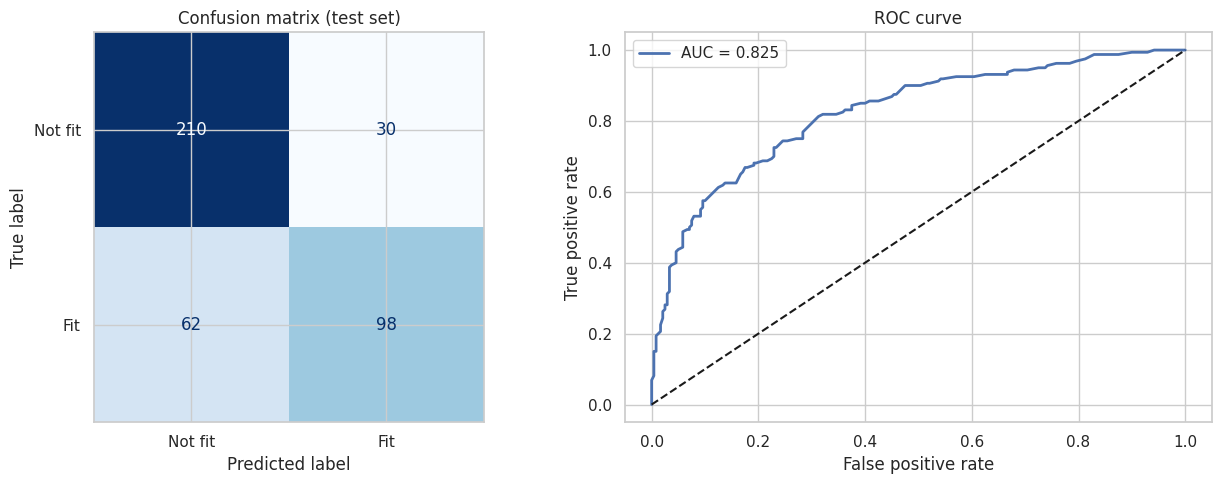

Train accuracy 1.0000 vs test accuracy 0.7700 (gap 0.2300)


In [8]:
# test set evaluation
# test set results
final_model = gs.best_estimator_
Xte = X_test[best_v['cols']]
final = evaluate(final_model, Xte, y_test)
print(f'{MODEL_NAME} | {best_variant} | {gs.best_params_}')
for k, v_ in final.items(): print(f'{k:>10}: {v_:.4f}')
print(); print(classification_report(y_test, final_model.predict(Xte), target_names=['Not fit', 'Fit']))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_estimator(final_model, Xte, y_test, display_labels=['Not fit', 'Fit'], cmap='Blues', ax=ax[0], colorbar=False)
ax[0].set_title('Confusion matrix (test set)')
fpr, tpr, _ = roc_curve(y_test, get_scores(final_model, Xte))
ax[1].plot(fpr, tpr, lw=2, label=f"AUC = {final['ROC_AUC']:.3f}"); ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('False positive rate'); ax[1].set_ylabel('True positive rate'); ax[1].set_title('ROC curve'); ax[1].legend()
plt.tight_layout(); plt.show()

tr = evaluate(final_model, X_train[best_v['cols']], y_train)
print(f"Train accuracy {tr['Accuracy']:.4f} vs test accuracy {final['Accuracy']:.4f} (gap {tr['Accuracy']-final['Accuracy']:.4f})")

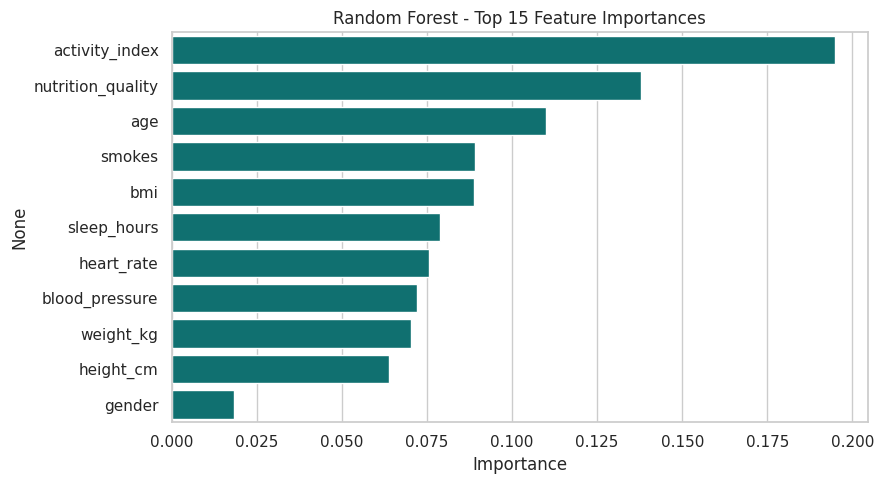

activity_index       0.1949
nutrition_quality    0.1380
age                  0.1099
smokes               0.0892
bmi                  0.0890
sleep_hours          0.0789
heart_rate           0.0756
blood_pressure       0.0722
weight_kg            0.0703
height_cm            0.0637
gender               0.0184


In [9]:
clf = final_model.named_steps['clf']
if best_v['pca']:
    print('PCA variant selected - importances refer to principal components, skipping feature names.')
else:
    imp = pd.Series(clf.feature_importances_, index=best_v['cols']).sort_values(ascending=False).head(15)
    plt.figure(figsize=(9,5)); sns.barplot(x=imp.values, y=imp.index, color='teal')
    plt.title('Random Forest - Top 15 Feature Importances'); plt.xlabel('Importance'); plt.tight_layout(); plt.show()
    print(imp.round(4).to_string())

In [10]:
# stability check
# stability check, 10 different random 80/20 splits
accs, f1s = [], []
for seed in range(10):
    Xa, Xb, ya, yb = train_test_split(X[best_v['cols']], y, test_size=0.20, random_state=seed, stratify=y)
    m_ = clone(final_model).fit(Xa, ya); n_fits += 1
    r_ = evaluate(m_, Xb, yb); accs.append(r_['Accuracy']); f1s.append(r_['F1'])
rep = dict(acc_mean=float(np.mean(accs)), acc_std=float(np.std(accs)), f1_mean=float(np.mean(f1s)), f1_std=float(np.std(f1s)),
           acc_min=float(np.min(accs)), acc_max=float(np.max(accs)))
print(f"Accuracy over 10 splits: {rep['acc_mean']:.4f} +/- {rep['acc_std']:.4f} (min {rep['acc_min']:.4f}, max {rep['acc_max']:.4f})")
print(f"F1 over 10 splits:       {rep['f1_mean']:.4f} +/- {rep['f1_std']:.4f}")

Accuracy over 10 splits: 0.7770 +/- 0.0247 (min 0.7375, max 0.8100)
F1 over 10 splits:       0.6986 +/- 0.0348


In [11]:
# summary and save results
total_configs = len(VARIANTS) + n_combos
print(f'Model: {MODEL_NAME}')
print(f'Configurations evaluated: {total_configs} ({len(VARIANTS)} preprocessing + {n_combos} hyperparameter combinations)')
print(f'Total fits incl. cross-validation: {n_fits}')
print(f'Best preprocessing: {best_variant}')
print(f'Best hyperparameters: {gs.best_params_}')
print(f"Test: Accuracy={final['Accuracy']:.4f} Precision={final['Precision']:.4f} Recall={final['Recall']:.4f} F1={final['F1']:.4f} AUC={final['ROC_AUC']:.4f}")

print('\n--- Conclusion ---')
print(f"Best preprocessing '{best_variant}' (CV F1 {res_A['CV F1 (mean)'].max():.4f}); worst '{res_A['CV F1 (mean)'].idxmin()}' ({res_A['CV F1 (mean)'].min():.4f}).")
print(f"Tuning moved test F1 from {res_A.loc[best_variant, 'Test F1']:.4f} to {final['F1']:.4f}.")
print(f"Train-test accuracy gap {tr['Accuracy']-final['Accuracy']:.4f}; accuracy over 10 splits {rep['acc_mean']:.4f} +/- {rep['acc_std']:.4f}.")

out = dict(member=MEMBER, student_id=STUDENT_ID, model=MODEL_NAME, best_variant=best_variant,
           best_params={k.replace('clf__', ''): (list(v_) if isinstance(v_, tuple) else v_) for k, v_ in gs.best_params_.items()},
           cv_f1=float(gs.best_score_), test={k: float(v_) for k, v_ in final.items()}, repeated=rep,
           train_acc=float(tr['Accuracy']), n_configs=int(total_configs), n_fits=int(n_fits),
           preprocessing_f1={k: float(v_) for k, v_ in res_A['CV F1 (mean)'].items()},
           preprocessing_test_acc={k: float(v_) for k, v_ in res_A['Test Acc'].items()})
with open(f'results_{STUDENT_ID}.json', 'w') as f: json.dump(out, f, indent=2, default=str)
print(f'Saved results_{STUDENT_ID}.json')

Model: Random Forest
Configurations evaluated: 24 (6 preprocessing + 18 hyperparameter combinations)
Total fits incl. cross-validation: 137
Best preprocessing: V4 Standard + BMI feature
Best hyperparameters: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Test: Accuracy=0.7700 Precision=0.7656 Recall=0.6125 F1=0.6806 AUC=0.8251

--- Conclusion ---
Best preprocessing 'V4 Standard + BMI feature' (CV F1 0.7035); worst 'V5 Standard, gender removed' (0.6789).
Tuning moved test F1 from 0.6667 to 0.6806.
Train-test accuracy gap 0.2300; accuracy over 10 splits 0.7770 +/- 0.0247.
Saved results_IT25101541.json
